# 1. Overfitting

Ejemplo sickit Learn [Link](https://scikit-learn.org/stable/auto_examples/model_selection/plot_underfitting_overfitting.html)

In [ ]:
# Importamos las librerías
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeRegressor

# Definimos una función que tomando un valor X devuelva un valor Y resultado de una función cosenoidal
def true_fun(X):
    return np.cos(1.5 * np.pi * X)

np.random.seed(0)

n_samples = 30

X = np.sort(np.random.rand(n_samples))
y = true_fun(X) + np.random.randn(n_samples) * 0.1

In [ ]:
print(X)
print(y)

[0.0202184  0.07103606 0.0871293  0.11827443 0.14335329 0.38344152
 0.41466194 0.4236548  0.43758721 0.46147936 0.52184832 0.52889492
 0.54488318 0.5488135  0.56804456 0.60276338 0.63992102 0.64589411
 0.71518937 0.77815675 0.78052918 0.79172504 0.79915856 0.83261985
 0.87001215 0.891773   0.92559664 0.94466892 0.96366276 0.97861834]
[ 1.0819082   0.87027612  1.14386208  0.70322051  0.78494746 -0.25265944
 -0.22066063 -0.26595867 -0.4562644  -0.53001927 -0.86481449 -0.99462675
 -0.87458603 -0.83407054 -0.77090649 -0.83476183 -1.03080067 -1.02544303
 -1.0788268  -1.00713288 -1.03009698 -0.63623922 -0.86230652 -0.75328767
 -0.70023795 -0.41043495 -0.50486767 -0.27907117 -0.25994628 -0.06189804]


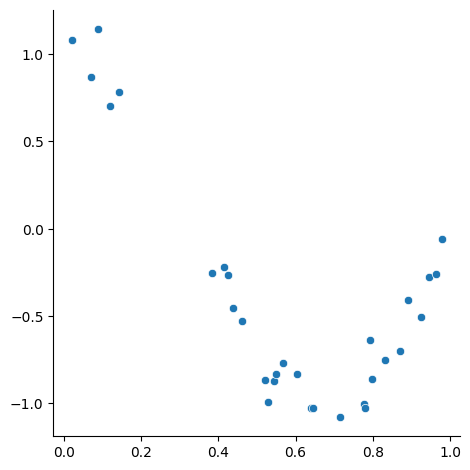

In [ ]:
# Pintamos los puntos de la muestra
import seaborn as sns
sns.relplot(x=X, y=y)

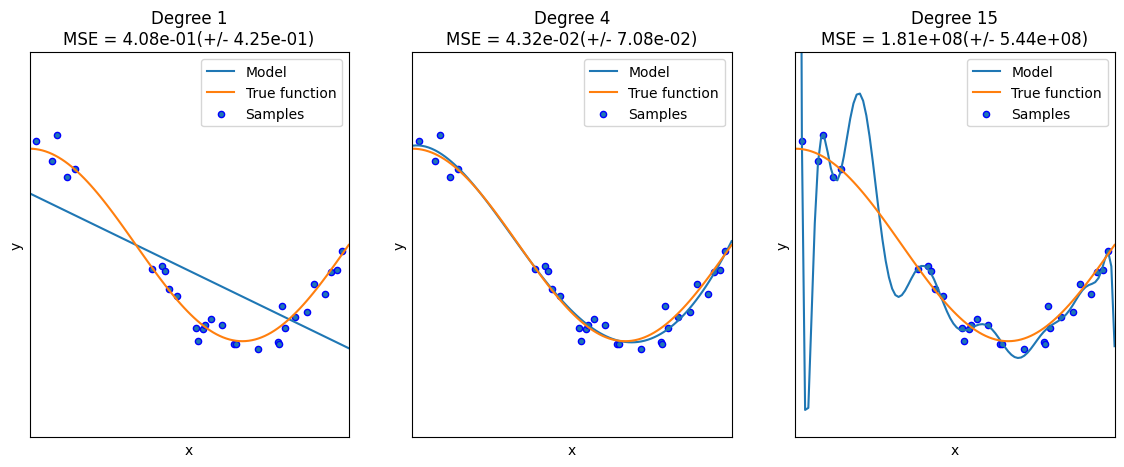

In [ ]:
# Entrenamos diferentes algoritmos (polinomios de diferentes grados)
degrees = [1, 4, 15]
plt.figure(figsize=(14, 5))

for i in range(len(degrees)):
    ax = plt.subplot(1, len(degrees), i + 1)
    plt.setp(ax, xticks=(), yticks=())

    polynomial_features = PolynomialFeatures(degree=degrees[i],
                                             include_bias=False)
    linear_regression = LinearRegression()
    pipeline = Pipeline([("polynomial_features", polynomial_features),
                         ("linear_regression", linear_regression)])
    pipeline.fit(X[:, np.newaxis], y)

    # Evaluamos el modelo usando cross validation
    scores = cross_val_score(pipeline, X[:, np.newaxis], y,
                             scoring="neg_mean_squared_error", cv=10)

    X_test = np.linspace(0, 1, 100)
    plt.plot(X_test, pipeline.predict(X_test[:, np.newaxis]), label="Model")
    plt.plot(X_test, true_fun(X_test), label="True function")
    plt.scatter(X, y, edgecolor='b', s=20, label="Samples")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.xlim((0, 1))
    plt.ylim((-2, 2))
    plt.legend(loc="best")
    plt.title("Degree {}\nMSE = {:.2e}(+/- {:.2e})".format(
        degrees[i], -scores.mean(), scores.std()))
plt.show()

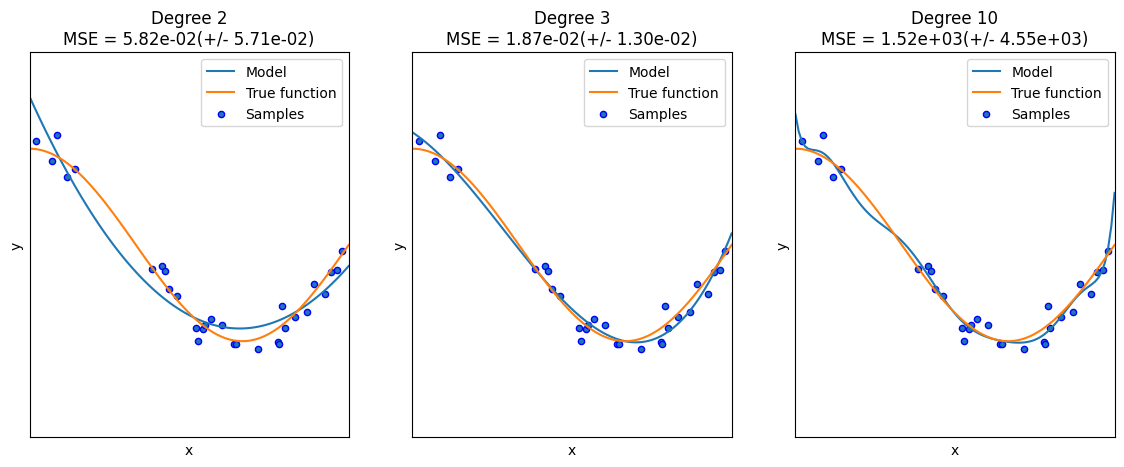

In [ ]:
# Modifica los valores numéricos de degrees para ver el overfitting

## Aquí
degrees = [2, 3, 10]

plt.figure(figsize=(14, 5))
for i in range(len(degrees)):
    ax = plt.subplot(1, len(degrees), i + 1)
    plt.setp(ax, xticks=(), yticks=())

    polynomial_features = PolynomialFeatures(degree=degrees[i],
                                             include_bias=False)
    linear_regression = LinearRegression()
    pipeline = Pipeline([("polynomial_features", polynomial_features),
                         ("linear_regression", linear_regression)])
    pipeline.fit(X[:, np.newaxis], y)

    # Evaluamos los modelos usando cross validation
    scores = cross_val_score(pipeline, X[:, np.newaxis], y,
                             scoring="neg_mean_squared_error", cv=10)

    X_test = np.linspace(0, 1, 100)
    plt.plot(X_test, pipeline.predict(X_test[:, np.newaxis]), label="Model")
    plt.plot(X_test, true_fun(X_test), label="True function")
    plt.scatter(X, y, edgecolor='b', s=20, label="Samples")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.xlim((0, 1))
    plt.ylim((-2, 2))
    plt.legend(loc="best")
    plt.title("Degree {}\nMSE = {:.2e}(+/- {:.2e})".format(
        degrees[i], -scores.mean(), scores.std()))
plt.show()

# 2. Métricas en un problema de Regresión

## 2.1 Modelo 1: Regresión Lineal

In [ ]:
# Importamos las funciones
import pandas as pd
import matplotlib.pyplot as plt

# Para que aparezca en el notebook
%matplotlib inline

In [ ]:
# Leemos los datos
data = pd.read_csv('https://raw.githubusercontent.com/justmarkham/scikit-learn-videos/master/data/Advertising.csv', index_col=0)
data.columns = ['TV','Radio','Newspaper','Sales']
data.head()

,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


In [ ]:
data.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [ ]:
# Creamos X e Y
feature_cols = ['TV']
X = data[feature_cols]
y = data.Sales

# Seguimos los pasos de entrenamiento
from sklearn.linear_model import LinearRegression
lm = LinearRegression()
lm.fit(X, y)

# Sacamos los coeficientes y el término constante
print(lm.intercept_)
print(lm.coef_)

7.032593549127695
[0.04753664]


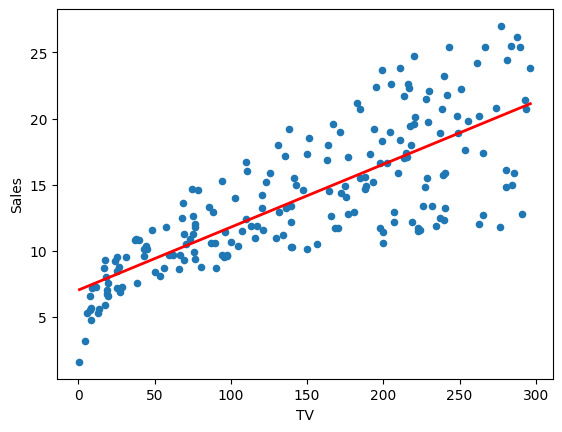

In [ ]:
X_new = pd.DataFrame({'TV': [data.TV.min(), data.TV.max()]})
X_new.head()

# Realizar predicciones
preds = lm.predict(X_new)
preds

# Plot dato observado
data.plot(kind='scatter', x='TV', y='Sales')

# Plot ajuste
plt.plot(X_new, preds, c='red', linewidth=2)

## 2.2 Modelo 2: Random Forest


In [ ]:
# 1) Importar la clase
from sklearn.tree import DecisionTreeRegressor

# 2) Crear el objeto rf, de la clase RandomForestRegressor, con max_depth =2
dt = DecisionTreeRegressor(max_depth=100)


# 3) Utilizar la X e y anteriores
data = pd.read_csv('https://raw.githubusercontent.com/justmarkham/scikit-learn-videos/master/data/Advertising.csv', index_col=0)
data.columns = ['TV','Radio','Newspaper','Sales']
feature_cols = ['TV','Radio','Newspaper']
X = data[feature_cols]
y = data.Sales

# Separamos train y test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(data.drop('Sales',axis=1),
                                                    data['Sales'],
                                                    test_size=0.25,
                                                    random_state=101)


In [ ]:
data.shape

(200, 4)

In [ ]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(150, 3)
(150,)
(50, 3)
(50,)


## 2.3 Comparativa entre modelos

In [ ]:
from sklearn.metrics import root_mean_squared_error
# Instanciamos el RandomForest y la Regresión Lineal
dt_2 = DecisionTreeRegressor(max_depth=15)
lm_2 = LinearRegression(fit_intercept=True)

# Ajuste
dt_2.fit(X_train,y_train)
lm_2.fit(X_train,y_train)

# Predicción
Y_test_lm = lm_2.predict(X_test)
Y_test_dt = dt_2.predict(X_test)

# Resultado
print("LM")
print(root_mean_squared_error(y_test, Y_test_lm))
print("DT")
print(root_mean_squared_error(y_test, Y_test_dt))

# TO DO: Re-ejecuta la celda con valores de max_depth 2, 5, 8

LM
1.4521047337632071
DT
1.1497825881443848


## 2.4 Optimización de parámetros y estudio del sobreajuste

In [ ]:
# Importamos las métricas
from sklearn import tree
from sklearn import metrics
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
# Definimos el tamaño del texto de las etiquetas en los plots
matplotlib.rc('xtick', labelsize=20)
matplotlib.rc('ytick', labelsize=20)
%matplotlib inline
train_mse_tot = []
test_mse_tot = []
# Iteramos sobre diferentes valores de profundidad
for depth in range(1, 50):
  # Inicializamos el modelo
  clf = tree.DecisionTreeRegressor(max_depth=depth)
  cols = ['TV','Radio','Newspaper']
  # Entrenamos el modelo
  clf.fit(X_train[cols], y_train)

  # Realizamos predicciones sobre el train y el test
  train_predictions = clf.predict(X_train[cols])
  test_predictions  = clf.predict(X_test[cols])

  # Calculamos el error cuadrático medio en train y test
  train_mse = metrics.mean_squared_error(y_train, train_predictions)
  test_mse = metrics.mean_squared_error(y_test, test_predictions)

  train_mse_tot.append(train_mse)
  test_mse_tot.append(test_mse)

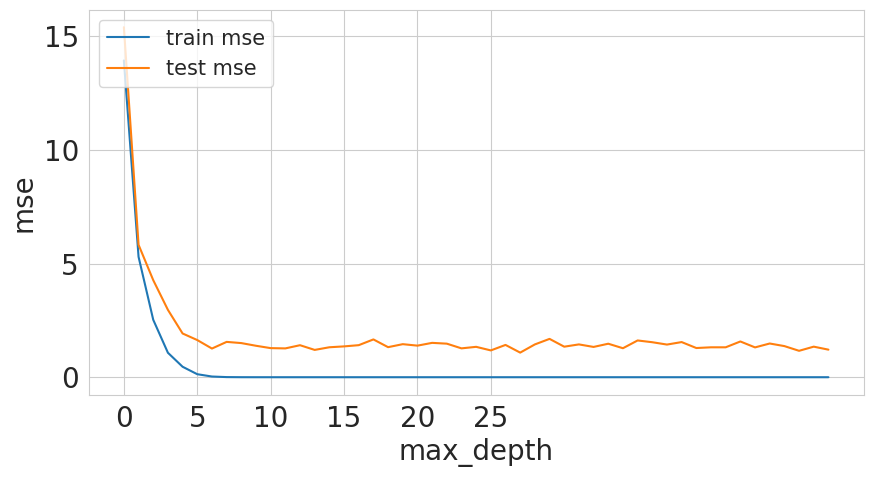

In [ ]:
# Representamos en un plot el error cuadrático medio para train y para test en función de la máxima profundidad del árbol
plt.figure(figsize=(10, 5))
sns.set_style("whitegrid")
plt.plot(train_mse_tot, label="train mse")
plt.plot(test_mse_tot, label="test mse")
plt.legend(loc="upper left", prop={'size': 15})
plt.xticks(range(0, 26, 5))
plt.xlabel("max_depth", size=20)
plt.ylabel("mse", size=20)
plt.show()

# 3. Ejemplo: Predicción precio de la vivienda

Lee el siguiente dataset de viviendas en Melbourne:

Link -> 'https://raw.githubusercontent.com/JimenaAreta/thevalley-MDS/refs/heads/jimena/datasets/melb_data.csv'

In [ ]:
import pandas as pd

In [ ]:
# Carga el dataframe
melbourne_data = pd.read_csv('https://raw.githubusercontent.com/JimenaAreta/thevalley-MDS/refs/heads/jimena/datasets/melb_data.csv')

In [ ]:
melbourne_data.isnull().sum()

,0
Suburb,0
Address,0
Rooms,0
Type,0
Price,0
Method,0
SellerG,0
Date,0
Distance,0
Postcode,0


In [ ]:
# Filtra las filas con valores nulos
filtered_melbourne_data = melbourne_data.dropna(axis=0)

In [ ]:
# Selecciona el target y las features (vamos a seleccionar como features : ['Rooms', 'Bathroom', 'Landsize', 'BuildingArea','YearBuilt', 'Lattitude', 'Longtitude'])
y = filtered_melbourne_data['Price']
X = filtered_melbourne_data[['Rooms', 'Bathroom', 'Landsize', 'BuildingArea','YearBuilt', 'Lattitude', 'Longtitude']]

In [ ]:
# Separa en train y en test (tanto el target como las features)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Para distintos valores del parámetro 'max_depth' entrena el modelo, saca las predicciones y las siguientes métricas (MAE, RMSE y R2)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
from sklearn.tree import DecisionTreeRegressor

def get_metrics(max_depth, train_X, val_X, train_y, val_y):
    model = DecisionTreeRegressor(max_depth=max_depth, random_state=0)
    model.fit(X_train, y_train)
    preds_train = model.predict(X_train)
    preds_test = model.predict(X_test)
    mae_train = mean_absolute_error(y_train, preds_train)
    mae_test = mean_absolute_error(y_test, preds_test)
    rmse_train = root_mean_squared_error(y_train, preds_train)
    rmse_test = root_mean_squared_error(y_test, preds_test)
    r2_train = r2_score(y_train, preds_train)
    r2_test = r2_score(y_test, preds_test)
    return(mae_train,mae_test,rmse_train,rmse_test,r2_train,r2_test)

In [ ]:
from sklearn.metrics import root_mean_squared_log_error

In [ ]:
mae_train_total = []
rmse_train_total = []
r2_train_total = []

mae_test_total = []
rmse_test_total = []
r2_test_total = []

depth_range = range(1, 20)

for max_depth in depth_range:
    mae_train,mae_test,rmse_train,rmse_test,r2_train,r2_test = get_metrics(max_depth, X_train, X_test, y_train, y_test)
    mae_train_total.append(mae_train)
    mae_test_total.append(mae_test)
    rmse_train_total.append(rmse_train)
    rmse_test_total.append(rmse_test)
    r2_train_total.append(r2_train)
    r2_test_total.append(r2_test)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

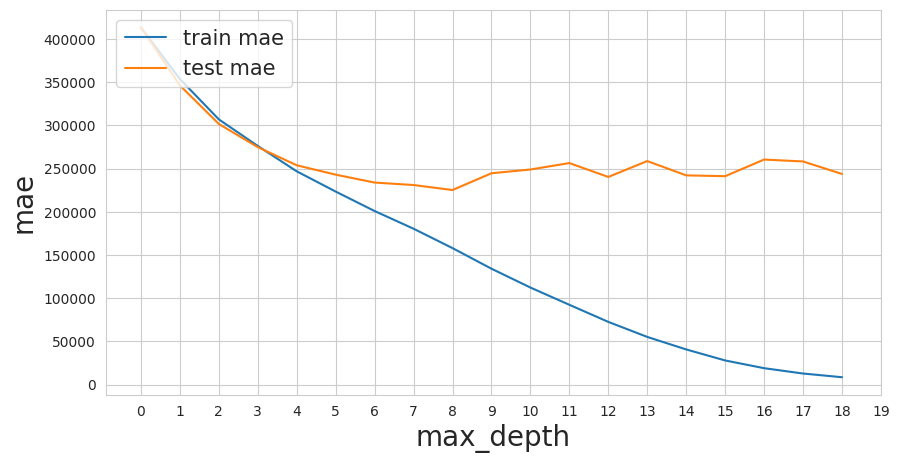

In [ ]:
# Representa en un gráfico en el eje X los valores de 'max_depth' y en la y el MAE para cada valor
plt.figure(figsize=(10, 5))
sns.set_style("whitegrid")
plt.plot(mae_train_total, label="train mae")
plt.plot(mae_test_total, label="test mae")
plt.legend(loc="upper left", prop={'size': 15})
plt.xticks(range(0, 20, 1))
plt.xlabel("max_depth", size=20)
plt.ylabel("mae", size=20)
plt.show()